# Случайный лес: теория и практика

Этот ноутбук — подробный разбор Random Forest: от одного дерева и bootstrap-выборок до декомпозиции bias–variance, OOB-оценки, важности признаков и настройки моделей классификации и регрессии.

## Содержание

1. Зачем объединять деревья
2. Bagging и bootstrap
3. Случайный лес и декорреляция деревьев
4. Математика классификации и регрессии
5. Bias–Variance Decomposition (BVD)
6. Почему усреднение уменьшает дисперсию
7. Out-of-Bag оценка
8. Реализация упрощённого случайного леса с нуля
9. Random Forest в `scikit-learn`
10. Важность признаков
11. Гиперпараметры и переобучение
12. Финальные визуализации


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, make_moons, make_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Зачем объединять деревья

Одно глубокое дерево обладает высокой гибкостью. Оно способно построить сложную границу решений и добиться почти нулевой ошибки на обучающей выборке, но небольшое изменение данных может сильно изменить первые разбиения и всю последующую структуру дерева.

Это проявление **высокой дисперсии** модели. Идея ансамбля состоит в том, чтобы обучить много отличающихся деревьев и объединить их прогнозы:

- в регрессии — усреднением;
- в классификации — голосованием или усреднением вероятностей классов.

Если ошибки отдельных деревьев не полностью совпадают, часть ошибок взаимно компенсируется. В результате лес обычно устойчивее одного глубокого дерева.


## 2. Bagging и bootstrap

**Bagging** расшифровывается как Bootstrap Aggregating и состоит из двух операций.

### 2.1. Bootstrap-выборка

Из исходной обучающей выборки размера $n$ случайно выбирают $n$ объектов **с возвращением**. Поэтому некоторые объекты попадают в bootstrap-выборку несколько раз, а некоторые не попадают ни разу.

Вероятность не выбрать конкретный объект за одно извлечение равна

$$1-\frac1n.$$

Вероятность не выбрать его ни разу за $n$ извлечений:

$$\left(1-\frac1n\right)^n\xrightarrow[n\to\infty]{}e^{-1}\approx0.368.$$

Следовательно, в одну bootstrap-выборку попадает примерно

$$1-e^{-1}\approx0.632$$

уникальных обучающих объектов. Оставшиеся $36.8\%$ называются Out-of-Bag объектами для данного дерева.

### 2.2. Aggregating

Пусть обучено $B$ моделей $f_1(x),\ldots,f_B(x)$.

В регрессии bagging-прогноз равен

$$\hat f_{bag}(x)=\frac1B\sum_{b=1}^{B}f_b(x).$$

В классификации можно усреднить вероятности:

$$\hat p_k(x)=\frac1B\sum_{b=1}^{B}\hat p_{bk}(x),$$

а затем выбрать класс

$$\hat y(x)=\arg\max_k\hat p_k(x).$$


In [2]:
n = 1000
bootstrap_indices = rng.integers(0, n, size=n)
unique_share = len(np.unique(bootstrap_indices)) / n
oob_share = 1 - unique_share

print(f"Доля уникальных объектов: {unique_share:.3f}")
print(f"Доля OOB-объектов: {oob_share:.3f}")


Доля уникальных объектов: 0.637
Доля OOB-объектов: 0.363


## 3. От bagging к случайному лесу

Обычный bagging обучает каждое дерево на своей bootstrap-выборке, но при каждом разбиении разрешает рассматривать все признаки. Если в данных есть один очень сильный признак, большинство деревьев выберет его около корня. Деревья станут похожими, а их ошибки — коррелированными.

**Random Forest** добавляет второй источник случайности: в каждом узле дерево рассматривает только случайное подмножество признаков. После выбора этого подмножества лучший признак и порог ищутся обычным способом.

Алгоритм обучения дерева $b$:

1. Создать bootstrap-выборку из исходных данных.
2. В каждом узле случайно выбрать $m$ признаков из общего числа $p$.
3. Найти лучший сплит только среди этих $m$ признаков.
4. Вырастить дерево с заданными ограничениями.
5. Повторить шаги для $B$ деревьев и агрегировать прогнозы.

Параметр `max_features` управляет величиной $m$. Уменьшение `max_features` обычно снижает корреляцию деревьев, но слишком малое значение может сделать каждое дерево слабым.


## 4. Математика прогноза

### 4.1. Классификация

Пусть дерево $b$ оценивает вероятность класса $k$ как долю объектов этого класса в достигнутом листе:

$$\hat p_{bk}(x)=\frac{n_{bk}(x)}{n_b(x)}.$$

Случайный лес усредняет вероятности всех деревьев:

$$\hat p_k(x)=\frac1B\sum_{b=1}^{B}\hat p_{bk}(x).$$

Итоговый класс:

$$\hat y(x)=\arg\max_{k\in\{1,\ldots,K\}}\hat p_k(x).$$

### 4.2. Регрессия

В листе дерева с критерием squared error прогноз равен среднему значению целевой переменной:

$$f_b(x)=\frac{1}{|R_b(x)|}\sum_{i:x_i\in R_b(x)}y_i.$$

Прогноз леса — среднее прогнозов деревьев:

$$\hat f_{RF}(x)=\frac1B\sum_{b=1}^{B}f_b(x).$$

Так как каждое дерево строит кусочно-постоянную функцию, их среднее также не умеет настоящую экстраполяцию за диапазон обучающих ответов.


## 5. Bias–Variance Decomposition (BVD)

Bias–Variance Decomposition объясняет, из каких источников складывается ожидаемая ошибка регрессионной модели на новых данных.

Предположим, данные порождаются моделью

$$y=f(x)+\varepsilon,$$

где

$$\mathbb E[\varepsilon\mid x]=0,
\qquad
\operatorname{Var}(\varepsilon\mid x)=\sigma^2.$$

Обучающая выборка $D$ случайна, поэтому обученный на ней прогноз $\hat f_D(x)$ также является случайной величиной. Для фиксированной точки $x$ ожидаемая квадратичная ошибка раскладывается так:

$$
\mathbb E_{D,\varepsilon}
\left[(y-\hat f_D(x))^2\right]
=
\underbrace{
\left(\mathbb E_D[\hat f_D(x)]-f(x)\right)^2
}_{\operatorname{Bias}^2(x)}
+
\underbrace{
\mathbb E_D\left[
(\hat f_D(x)-\mathbb E_D[\hat f_D(x)])^2
\right]
}_{\operatorname{Variance}(x)}
+
\underbrace{\sigma^2}_{\text{неустранимый шум}}
$$

### 5.1. Смещение

$$\operatorname{Bias}(x)=\mathbb E_D[\hat f_D(x)]-f(x).$$

Смещение показывает систематическую ошибку модели. Неглубокое дерево имеет ограниченную сложность, поэтому обычно обладает повышенным bias и может недообучаться.

### 5.2. Дисперсия

$$\operatorname{Variance}(x)=\mathbb E_D\left[(\hat f_D(x)-\mathbb E_D[\hat f_D(x)])^2\right].$$

Дисперсия показывает чувствительность модели к составу обучающей выборки. Глубокое дерево обычно имеет низкий bias, но высокую variance.

### 5.3. Неустранимый шум

$\sigma^2$ связан со случайностью самого процесса генерации данных. Его невозможно устранить выбором алгоритма, даже если истинная функция $f(x)$ известна.

### 5.4. Где находится Random Forest

Random Forest усредняет много глубоких деревьев. Главное преимущество усреднения — существенное уменьшение variance. Bias обычно меняется намного слабее. Поэтому лес часто сохраняет способность деревьев описывать сложные зависимости, но становится стабильнее.

Для классификации точное классическое разложение квадратичной ошибки неприменимо непосредственно к ошибке 0–1. Однако идея bias–variance остаётся полезной: одиночное дерево нестабильно, а усреднение вероятностей множества декоррелированных деревьев делает решение устойчивее.


## 6. Почему усреднение уменьшает дисперсию

Предположим, прогнозы всех деревьев имеют одинаковую дисперсию $\sigma_T^2$, а корреляция между любыми двумя деревьями равна $\rho$. Тогда дисперсия среднего из $B$ деревьев равна

$$
\operatorname{Var}\left(\frac1B\sum_{b=1}^{B}f_b(x)\right)
=
\rho\sigma_T^2+
\frac{1-\rho}{B}\sigma_T^2.
$$

Из формулы следуют два важных вывода:

1. При увеличении числа деревьев второе слагаемое стремится к нулю.
2. Первое слагаемое остаётся даже при бесконечном числе деревьев и определяется корреляцией $\rho$.

Если деревья полностью независимы ($\rho=0$), дисперсия уменьшается примерно в $B$ раз. Если деревья одинаковы ($\rho=1$), усреднение не даёт выигрыша. Поэтому Random Forest не только создаёт разные bootstrap-выборки, но и случайно ограничивает признаки в каждом узле — это декоррелирует деревья.


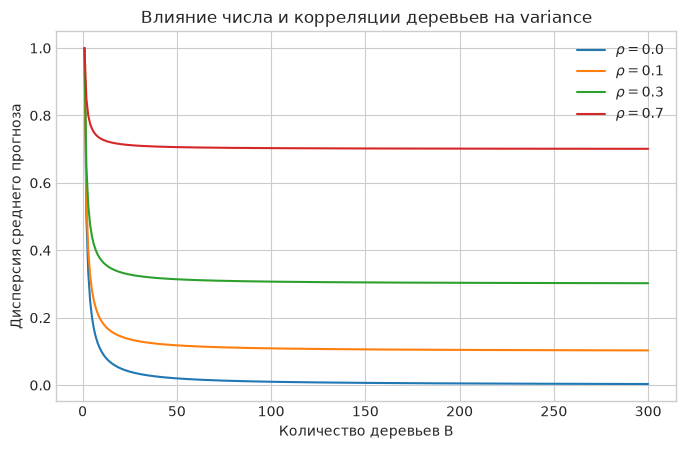

In [3]:
B = np.arange(1, 301)
sigma2 = 1

plt.figure(figsize=(8, 4.8))
for rho in [0.0, 0.1, 0.3, 0.7]:
    variance = rho * sigma2 + (1 - rho) * sigma2 / B
    plt.plot(B, variance, label=fr"$\rho={rho}$")
plt.xlabel("Количество деревьев B")
plt.ylabel("Дисперсия среднего прогноза")
plt.title("Влияние числа и корреляции деревьев на variance")
plt.legend()
plt.show()


График показывает убывающую отдачу от новых деревьев. При высокой корреляции ансамбль быстро выходит на высокое плато. Снижение корреляции может быть важнее простого увеличения `n_estimators`.


## 7. Эмпирическая демонстрация BVD

Истинная функция известна:

$$f(x)=\sin(x).$$

Многократно создадим новые обучающие выборки с шумом, обучим дерево и случайный лес, а затем сравним их прогнозы в одних и тех же точках. Средний прогноз позволит оценить bias, а разброс прогнозов между выборками — variance.


In [4]:
x_grid = np.linspace(0, 2 * np.pi, 200)
f_true = np.sin(x_grid)
n_repeats = 80
tree_predictions = []
forest_predictions = []

for seed in range(n_repeats):
    local_rng = np.random.default_rng(seed)
    X_sample = local_rng.uniform(0, 2 * np.pi, 70).reshape(-1, 1)
    y_sample = np.sin(X_sample[:, 0]) + local_rng.normal(0, 0.3, len(X_sample))
    tree = DecisionTreeRegressor(random_state=seed)
    forest = RandomForestRegressor(n_estimators=120, max_features=0.7, n_jobs=-1, random_state=seed)
    tree.fit(X_sample, y_sample)
    forest.fit(X_sample, y_sample)
    tree_predictions.append(tree.predict(x_grid.reshape(-1, 1)))
    forest_predictions.append(forest.predict(x_grid.reshape(-1, 1)))

tree_predictions = np.asarray(tree_predictions)
forest_predictions = np.asarray(forest_predictions)

tree_bias2 = np.mean((tree_predictions.mean(axis=0) - f_true) ** 2)
forest_bias2 = np.mean((forest_predictions.mean(axis=0) - f_true) ** 2)
tree_variance = np.mean(tree_predictions.var(axis=0))
forest_variance = np.mean(forest_predictions.var(axis=0))

pd.DataFrame({
    "Модель": ["Одно дерево", "Случайный лес"],
    "Bias²": [tree_bias2, forest_bias2],
    "Variance": [tree_variance, forest_variance]
}).round(4)


,Модель,Bias²,Variance
0,Одно дерево,0.0012,0.0879
1,Случайный лес,0.0009,0.0418


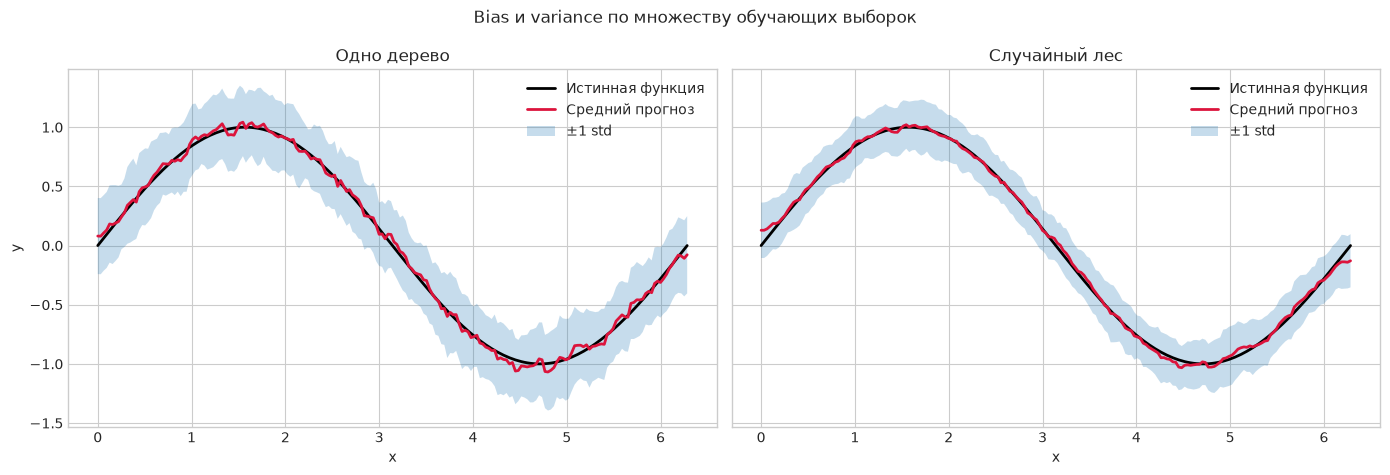

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, predictions, title in zip(
    axes,
    [tree_predictions, forest_predictions],
    ["Одно дерево", "Случайный лес"]
):
    mean_prediction = predictions.mean(axis=0)
    std_prediction = predictions.std(axis=0)
    ax.plot(x_grid, f_true, color="black", linewidth=2, label="Истинная функция")
    ax.plot(x_grid, mean_prediction, color="crimson", linewidth=2, label="Средний прогноз")
    ax.fill_between(x_grid, mean_prediction - std_prediction, mean_prediction + std_prediction, alpha=0.25, label="±1 std")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend()

axes[0].set_ylabel("y")
plt.suptitle("Bias и variance по множеству обучающих выборок")
plt.tight_layout()
plt.show()


Ширина закрашенной области отражает изменчивость прогнозов при замене обучающей выборки. У случайного леса она обычно заметно уже: ансамбль уменьшает variance одиночного дерева. Конкретные численные оценки зависят от размера выборки, шума и гиперпараметров.


## 8. Out-of-Bag оценка

Для каждого дерева примерно $36.8\%$ объектов не попадают в его bootstrap-выборку. Эти объекты можно использовать как локальную проверочную выборку.

Для объекта $x_i$ берутся только те деревья, для которых он был OOB, и их прогнозы агрегируются. После этого качество вычисляется по всем объектам, имеющим OOB-прогноз.

Преимущества:

- не требуется выделять отдельную validation-выборку;
- почти все данные используются для обучения каждого дерева ансамбля;
- можно быстро оценивать качество разных конфигураций леса.

OOB-оценка не заменяет финальную тестовую выборку, которую нельзя использовать при выборе модели.


In [ ]:
X_cancer, y_cancer = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.25, stratify=y_cancer, random_state=42
)

oob_forest = RandomForestClassifier(
    n_estimators=400,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
oob_forest.fit(X_train, y_train)
test_accuracy = accuracy_score(y_test, oob_forest.predict(X_test))

print(f"OOB accuracy:  {oob_forest.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


## 9. Упрощённый Random Forest с нуля

Ниже показана учебная реализация классификатора. Каждое дерево получает собственную bootstrap-выборку, а `DecisionTreeClassifier` случайно выбирает признаки в каждом узле через `max_features`.


In [ ]:
class SimpleRandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=None, max_features="sqrt", random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        generator = np.random.default_rng(self.random_state)
        self.classes_ = np.unique(y)
        self.trees_ = []

        for _ in range(self.n_estimators):
            indices = generator.integers(0, len(X), size=len(X))
            seed = int(generator.integers(0, 2**31 - 1))
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                max_features=self.max_features,
                random_state=seed
            )
            tree.fit(X[indices], y[indices])
            self.trees_.append(tree)

        return self

    def predict_proba(self, X):
        probabilities = np.zeros((len(X), len(self.classes_)))

        for tree in self.trees_:
            tree_probabilities = tree.predict_proba(X)
            for column, class_label in enumerate(tree.classes_):
                target_column = np.where(self.classes_ == class_label)[0][0]
                probabilities[:, target_column] += tree_probabilities[:, column]

        return probabilities / self.n_estimators

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]


In [ ]:
simple_forest = SimpleRandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    random_state=42
)
simple_forest.fit(X_train, y_train)
simple_accuracy = accuracy_score(y_test, simple_forest.predict(X_test))

sklearn_forest = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
sklearn_forest.fit(X_train, y_train)
sklearn_accuracy = accuracy_score(y_test, sklearn_forest.predict(X_test))

print(f"Simple Random Forest:  {simple_accuracy:.4f}")
print(f"sklearn Random Forest: {sklearn_accuracy:.4f}")


## 10. Random Forest в `scikit-learn`

Основные классы:

- `RandomForestClassifier` — классификация;
- `RandomForestRegressor` — регрессия.

### 10.1. Основные гиперпараметры

- `n_estimators` — число деревьев. Больше деревьев обычно стабилизирует качество, но увеличивает время и память.
- `max_features` — число признаков-кандидатов в каждом узле. Это ключевой параметр декорреляции.
- `max_depth` — максимальная глубина каждого дерева.
- `min_samples_split` — минимальное число объектов для деления узла.
- `min_samples_leaf` — минимальное число объектов в листе.
- `max_leaf_nodes` — максимальное число листьев.
- `bootstrap=True` — обучение деревьев на bootstrap-выборках.
- `max_samples` — размер bootstrap-выборки для каждого дерева.
- `oob_score=True` — вычисление OOB-качества.
- `class_weight='balanced'` — коррекция дисбаланса классов.
- `criterion` — критерий разбиения отдельных деревьев.
- `n_jobs=-1` — параллельное обучение на всех доступных ядрах.
- `random_state` — воспроизводимость.

Масштабирование признаков случайному лесу обычно не требуется: дерево сравнивает значения с порогами, а монотонное изменение масштаба не меняет порядок объектов.


## 11. Классификация

Сравним одно глубокое дерево и случайный лес на нелинейном датасете `make_moons`.


In [ ]:
X_moons, y_moons = make_moons(n_samples=700, noise=0.28, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.3, stratify=y_moons, random_state=42
)

tree_classifier = DecisionTreeClassifier(random_state=42)
forest_classifier = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

tree_classifier.fit(X_train_m, y_train_m)
forest_classifier.fit(X_train_m, y_train_m)

print(f"Decision Tree accuracy: {accuracy_score(y_test_m, tree_classifier.predict(X_test_m)):.4f}")
print(f"Random Forest accuracy: {accuracy_score(y_test_m, forest_classifier.predict(X_test_m)):.4f}")


## 12. Регрессия

В регрессии среднее по деревьям сглаживает резкие изменения отдельных кусочно-постоянных моделей.


In [ ]:
X_reg, y_reg = make_regression(
    n_samples=900,
    n_features=10,
    n_informative=7,
    noise=25,
    random_state=42
)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

tree_regressor = DecisionTreeRegressor(random_state=42)
forest_regressor = RandomForestRegressor(
    n_estimators=350,
    max_features=0.8,
    n_jobs=-1,
    random_state=42
)

tree_regressor.fit(X_train_r, y_train_r)
forest_regressor.fit(X_train_r, y_train_r)

for name, model in [("Decision Tree", tree_regressor), ("Random Forest", forest_regressor)]:
    predictions = model.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, predictions))
    r2 = r2_score(y_test_r, predictions)
    print(f"{name:13s} | RMSE: {rmse:7.2f} | R²: {r2:.4f}")


## 13. Важность признаков

### 13.1. Mean Decrease in Impurity

Встроенная важность `feature_importances_` суммирует уменьшения загрязнённости, созданные признаком во всех узлах и деревьях, с учётом доли объектов в узле:

$$
FI_j=
\frac1B\sum_{b=1}^{B}
\sum_{t:\,v(t)=j}
\frac{N_t}{N}
\Delta I_t.
$$

Здесь $v(t)$ — признак разбиения в узле $t$, $N_t$ — число объектов узла, а $\Delta I_t$ — уменьшение загрязнённости.

Недостатки impurity importance:

- предпочтение признакам с большим числом возможных порогов;
- важность может распределяться между коррелирующими признаками;
- величина показывает использование признака моделью, но не причинное влияние.

### 13.2. Permutation Importance

Значения одного признака перемешиваются, разрушая его связь с целевой переменной. Падение качества показывает, насколько модель зависела от этого признака:

$$PI_j=Score(X,y)-Score(X_{perm(j)},y).$$

Permutation importance следует вычислять на validation- или test-данных, не использованных для обучения.


In [ ]:
feature_names = load_breast_cancer().feature_names
permutation = permutation_importance(
    oob_forest,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_table = pd.DataFrame({
    "feature": feature_names,
    "impurity_importance": oob_forest.feature_importances_,
    "permutation_importance": permutation.importances_mean
}).sort_values("permutation_importance", ascending=False)

importance_table.head(10)


In [ ]:
top_importance = importance_table.head(10).sort_values("permutation_importance")

plt.figure(figsize=(9, 5.5))
plt.barh(top_importance["feature"], top_importance["permutation_importance"], color="steelblue")
plt.xlabel("Среднее падение accuracy")
plt.title("Permutation importance: 10 важнейших признаков")
plt.tight_layout()
plt.show()


## 14. Настройка гиперпараметров

Для леса особенно важны:

- сложность отдельных деревьев: `max_depth`, `min_samples_leaf`;
- сила декорреляции: `max_features`;
- размер ансамбля: `n_estimators`;
- размер bootstrap-выборки: `max_samples`.

`n_estimators` обычно не вызывает классического переобучения: после некоторого числа деревьев качество выходит на плато. Однако вычислительные затраты продолжают расти.

Большие `min_samples_leaf` и малые `max_depth` уменьшают variance, но увеличивают bias. Малое `max_features` снижает корреляцию деревьев, но при слишком сильном ограничении повышает bias отдельных деревьев. Это прямое проявление bias–variance tradeoff.


In [ ]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 16],
    "max_features": ["sqrt", 0.7],
    "min_samples_leaf": [1, 3, 7]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print(f"CV accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")


## 15. Финальная визуализация классификации

Сравним границы решений одного дерева и случайного леса. Лес усредняет множество ступенчатых границ и обычно формирует более устойчивое решение.


In [ ]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )
    probabilities = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    probabilities = probabilities.reshape(xx.shape)
    ax.contourf(xx, yy, probabilities, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.65)
    ax.contour(xx, yy, probabilities, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="white", s=28)
    ax.set_title(title)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_decision_boundary(tree_classifier, X_test_m, y_test_m, axes[0], "Одно дерево")
plot_decision_boundary(forest_classifier, X_test_m, y_test_m, axes[1], "Случайный лес")
plt.tight_layout()
plt.show()


## 16. Финальная визуализация регрессии

Покажем прогноз одного дерева и случайного леса на одномерной нелинейной зависимости.


In [ ]:
X_curve = np.linspace(0, 6, 100).reshape(-1, 1)
y_curve = np.sin(X_curve[:, 0]) + rng.normal(0, 0.18, len(X_curve))
X_dense = np.linspace(0, 6, 600).reshape(-1, 1)

tree_curve = DecisionTreeRegressor(max_depth=6, random_state=42)
forest_curve = RandomForestRegressor(
    n_estimators=300,
    max_features=1.0,
    n_jobs=-1,
    random_state=42
)
tree_curve.fit(X_curve, y_curve)
forest_curve.fit(X_curve, y_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model, title in zip(
    axes,
    [tree_curve, forest_curve],
    ["Одно дерево", "Случайный лес"]
):
    ax.scatter(X_curve[:, 0], y_curve, s=24, alpha=0.7)
    ax.plot(X_dense[:, 0], model.predict(X_dense), color="crimson", linewidth=2.5)
    ax.set_title(title)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
plt.suptitle("Регрессия: усреднение прогнозов деревьев")
plt.tight_layout()
plt.show()


## 17. Резюме

- Random Forest объединяет bootstrap, случайный выбор признаков и агрегирование прогнозов.
- Глубокое дерево обычно имеет низкий bias и высокую variance.
- Усреднение множества деревьев прежде всего уменьшает variance.
- Чем слабее коррелируют ошибки деревьев, тем эффективнее ансамбль.
- `max_features` создаёт декорреляцию, а `n_estimators` стабилизирует средний прогноз.
- OOB-объекты позволяют оценить качество без отдельной validation-выборки.
- Масштабирование признаков обычно не требуется.
- Impurity importance удобна, но может быть смещённой; permutation importance надёжнее интерпретировать на отложенных данных.
- Лес хорошо моделирует нелинейности и взаимодействия, но практически не экстраполирует за обучающий диапазон.
- Гиперпараметры глубины и размера листа управляют bias–variance tradeoff отдельных деревьев.
